In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Load the Iris dataset directly from scikit-learn
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Display basic exploratory data
print("--- First 5 Rows ---")
print(df.head())

print("\n--- Shape of Dataset ---")
print(df.shape)

print("\n--- Missing Values ---")
print(df.isnull().sum())



--- First 5 Rows ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

--- Shape of Dataset ---
(150, 5)

--- Missing Values ---
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [2]:
# Display summary statistics of the dataset
print("--- Summary Statistics ---")
display(df.describe())

--- Summary Statistics ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


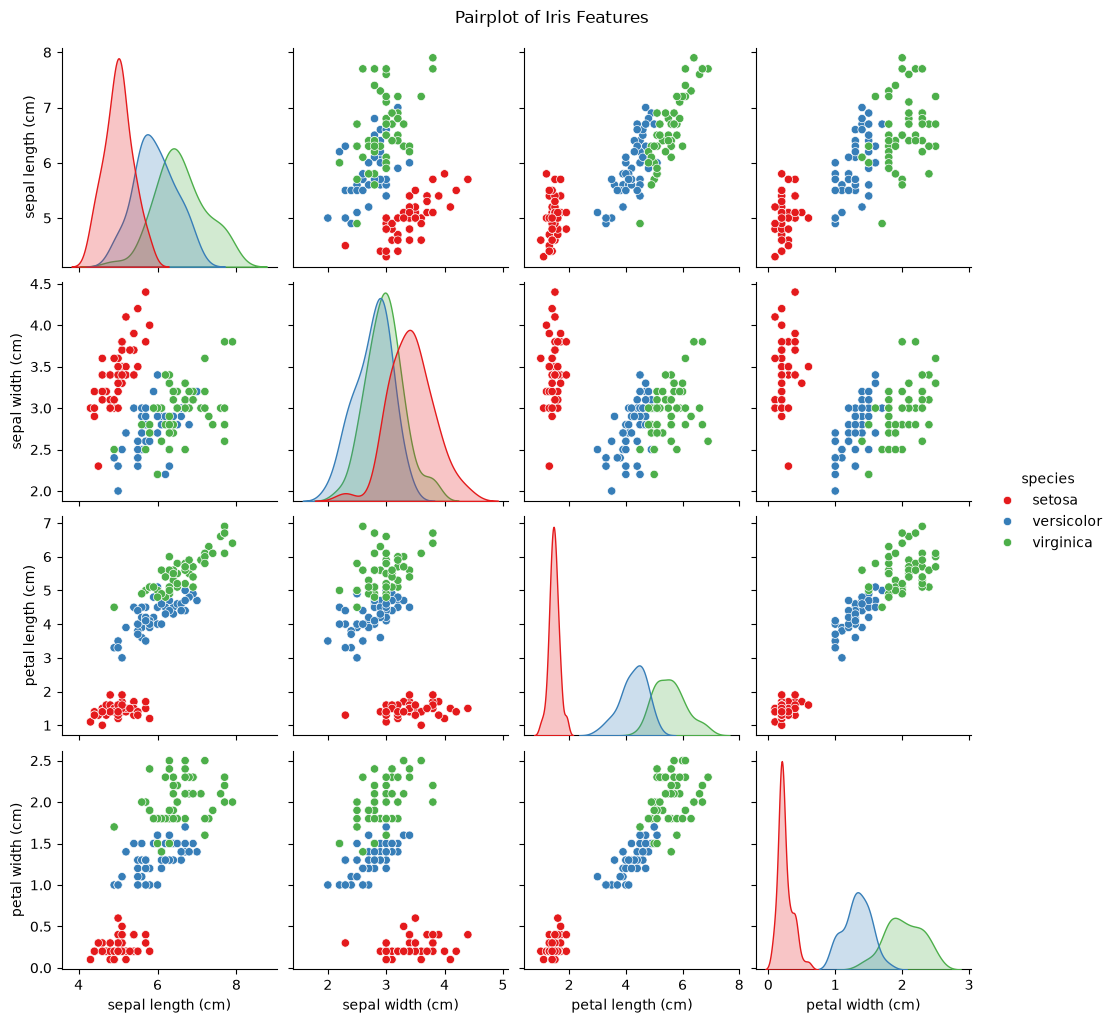

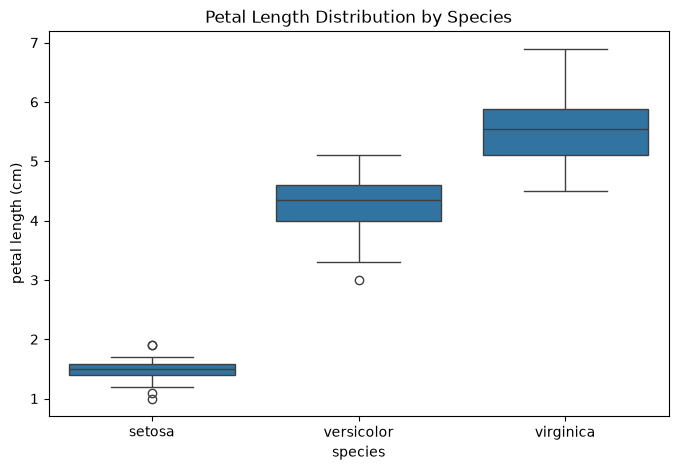

In [3]:
# Create graphs to visualize species differences
sns.pairplot(df, hue='species', palette='Set1')
plt.suptitle("Pairplot of Iris Features", y=1.02)
plt.show()

# Boxplot comparing Petal Length across species
plt.figure(figsize=(8, 5))
sns.boxplot(x='species', y='petal length (cm)', data=df)
plt.title("Petal Length Distribution by Species")
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Separate features (X) and target label (y)
X = df.drop('species', axis=1)
y = df['species']

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Decision Tree Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_test if False else y_train)

# Make predictions on test data
y_pred = model.predict(X_test)

# Print Evaluation Metrics
print("--- Model Accuracy ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Model Accuracy ---
Accuracy: 100.00%

--- Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [5]:
from sklearn.linear_model import LogisticRegression

# Initialize and train Logistic Regression Model
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train)

# Make predictions on test data
lr_pred = lr_model.predict(X_test)

# Print Evaluation Metrics
print("--- Logistic Regression Model Accuracy ---")
print(f"Accuracy: {accuracy_score(y_test, lr_pred) * 100:.2f}%\n")

print("--- Logistic Regression Classification Report ---")
print(classification_report(y_test, lr_pred))

--- Logistic Regression Model Accuracy ---
Accuracy: 100.00%

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Model Comparison & Best Model Declaration

* **Decision Tree Classifier Accuracy:** 100.00%
* **Logistic Regression Classifier Accuracy:** 100.00%

**Conclusion:**
Both models achieved 100% accuracy on the test set. **Logistic Regression** is declared as the best-performing model for the Iris dataset because it creates a smooth linear decision boundary, reducing the risk of overfitting compared to a Decision Tree while offering lower computational complexity.